In [2]:
import pandas as pd

# Load datasets
orders = pd.read_csv("orders.csv")
customers = pd.read_csv("customer.csv")

# Preview
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,18-11-2017 19:45,22-11-2017 13:39,02-12-2017 00:28,15-12-2017 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,13-02-2018 22:20,14-02-2018 19:46,16-02-2018 18:17,26-02-2018 00:00


In [5]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'],
    format='%d-%m-%Y %H:%M'
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date'],
    format='%d-%m-%Y %H:%M'
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date'],
    format='%d-%m-%Y %H:%M'
)

In [6]:
orders = orders.dropna(subset=['order_delivered_customer_date'])

In [7]:
data = orders.merge(customers, on='customer_id', how='left')

In [8]:
# Delivery time
data['delivery_time'] = (
    data['order_delivered_customer_date'] - data['order_purchase_timestamp']
).dt.days

# Delay days
data['delay_days'] = (
    data['order_delivered_customer_date'] - data['order_estimated_delivery_date']
).dt.days

# Delay flag
data['is_delayed'] = data['delay_days'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
#First Insights
#1. Total delayed orders
data['is_delayed'].value_counts()

is_delayed
0    89941
1     6535
Name: count, dtype: int64

In [10]:
#Average delivery time
data['delivery_time'].mean()

np.float64(12.094510551847092)

In [11]:
#Delay percentage
delay_percent = data['is_delayed'].mean() * 100
print(f"Delay %: {delay_percent:.2f}%")

Delay %: 6.77%


In [12]:
# Region-wise Analysis
region_perf = data.groupby('customer_state').agg({
    'delivery_time': 'mean',
    'is_delayed': 'mean'
}).reset_index()

region_perf['delay_%'] = region_perf['is_delayed'] * 100

region_perf.sort_values(by='delay_%', ascending=False).head()

,customer_state,delivery_time,is_delayed,delay_%
1,AL,24.040302,0.214106,21.410579
9,MA,21.117155,0.174338,17.433752
24,SE,21.029851,0.152239,15.223881
16,PI,18.993697,0.138655,13.865546
5,CE,20.817826,0.137608,13.760751


In [14]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------------ --------- 6.3/8.3 MB 31.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 26.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 21.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   --------------------------------- ------ 6.0/7.2 MB 28.9 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 24.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   -----------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


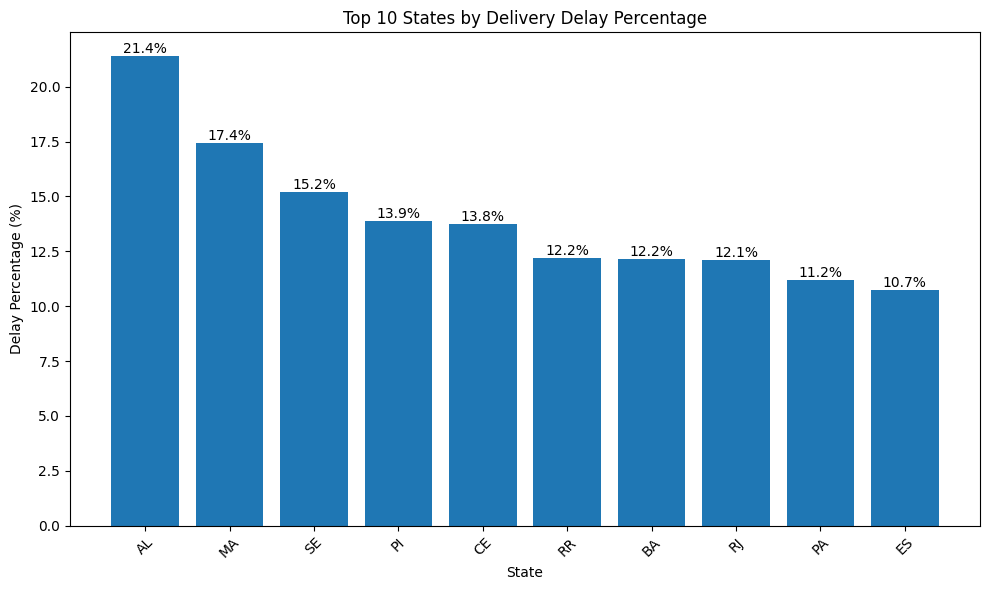

In [16]:
#Delay % by Region (Most Important Chart)
import matplotlib.pyplot as plt

# Sort and get top 10 delayed states
top_states = region_perf.sort_values(by='delay_%', ascending=False).head(10)

plt.figure(figsize=(10, 6))

bars = plt.bar(top_states['customer_state'], top_states['delay_%'])

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}%', ha='center', va='bottom')

plt.title("Top 10 States by Delivery Delay Percentage")
plt.xlabel("State")
plt.ylabel("Delay Percentage (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

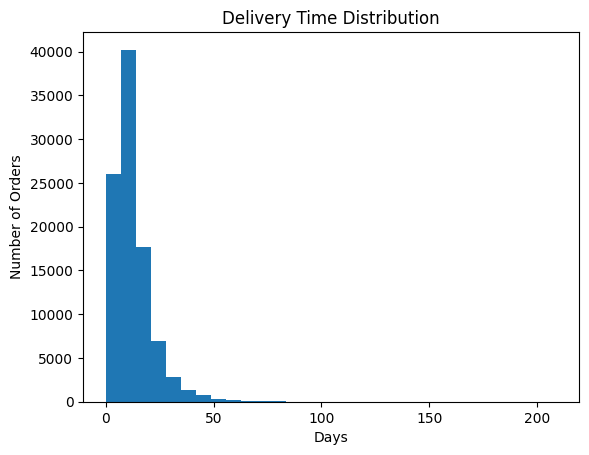

In [20]:
#Delivery Time Distribution
plt.figure()
plt.hist(data['delivery_time'], bins=30)
plt.title("Delivery Time Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Orders")

plt.show()

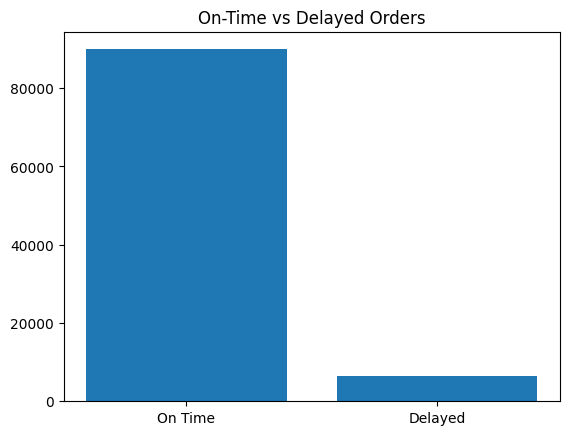

In [21]:
#Delayed vs On-Time Orders
delay_counts = data['is_delayed'].value_counts()

plt.figure()
plt.bar(['On Time', 'Delayed'], delay_counts.values)
plt.title("On-Time vs Delayed Orders")
plt.show()

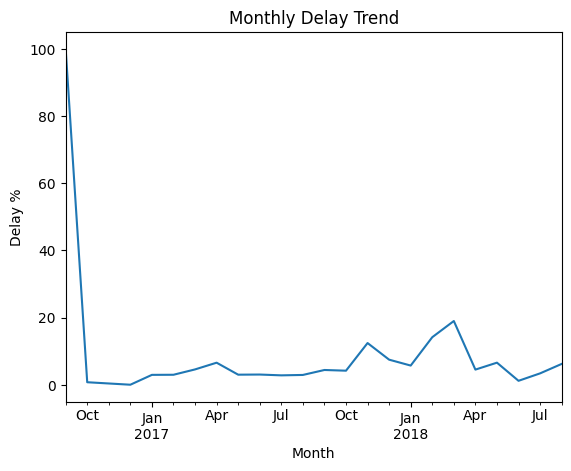

In [22]:
#Monthly Trend (🔥 Important for business)
data['month'] = data['order_purchase_timestamp'].dt.to_period('M')

monthly_delay = data.groupby('month')['is_delayed'].mean() * 100

monthly_delay.plot()
plt.title("Monthly Delay Trend")
plt.xlabel("Month")
plt.ylabel("Delay %")
plt.show()

In [26]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------- ----------- 5.8/8.1 MB 30.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 25.0 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.7/37.3 MB 18.1 MB/s eta 0:00:02
   ------- -------------------------------- 7.1/37.3 MB 17.1 MB/s eta 0:00:02
   ----------- ---------------------------- 10.5/37.3 MB 17.0 MB/s eta 0:00:02
   -------------- ------------------------- 13.6/37.3 MB 16.6 MB/s eta 0:00:02
   ----------------- ---------------------- 16.0/37.3 MB 15.6 MB/s eta 0:00:02
   ------------------- -------------------- 18.4/37.3 MB 14.8 MB/s eta 0:00:02
   --------------------- ------------------ 20.4/37.3 MB 14.2 MB/s eta 0:00:02
   ------------------------ --------------- 22.5/37.3 MB 13.7 MB/s eta 0:00:02
   -------------------------- ------------- 24.9/37.3 MB 13.4 MB/s eta 0:00:01
 


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
#Machine Learning (Prediction)
from sklearn.model_selection import train_test_split

# Select features
features = data[['delivery_time']]  # we'll improve this
target = data['is_delayed']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

In [28]:
#Train Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
#Evaluate
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.9598362354892206


In [30]:
#Time-Based Features (VERY IMPORTANT)
data['purchase_hour'] = data['order_purchase_timestamp'].dt.hour
data['purchase_dayofweek'] = data['order_purchase_timestamp'].dt.dayofweek
data['purchase_day'] = data['order_purchase_timestamp'].dt.day
data['purchase_month'] = data['order_purchase_timestamp'].dt.month
data['is_weekend'] = data['purchase_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

In [31]:
#Delivery Time Gaps
# Time taken to ship (if shipping date exists)
data['processing_time'] = (
    data['order_delivered_customer_date'] - data['order_purchase_timestamp']
).dt.days

# Expected delivery window
data['expected_delivery_days'] = (
    data['order_estimated_delivery_date'] - data['order_purchase_timestamp']
).dt.days

In [32]:
#Location-Based Features
# Encode state
data = pd.get_dummies(data, columns=['customer_state'], drop_first=True)

In [34]:
#importing order_items.csv
import pandas as pd

order_items = pd.read_csv("order_items.csv")

In [35]:
#Order-Level Features (If using order_items): - Merge order_items.csv first.
order_items_grouped = order_items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()

data = data.merge(order_items_grouped, on='order_id', how='left')

In [36]:
#creating freight value + price feature
data['total_order_value'] = data['price'] + data['freight_value']

In [38]:
data = data.merge(order_items[['order_id', 'seller_id']], 
                  on='order_id', 
                  how='left')

In [39]:
#seller behaviour features (if using order_items)
seller_perf = data.groupby('seller_id')['is_delayed'].mean().reset_index()
seller_perf.columns = ['seller_id', 'seller_delay_rate']

data = data.merge(seller_perf, on='seller_id', how='left')

In [40]:
#final model train
from sklearn.model_selection import train_test_split

X = data.drop(columns=[
    'is_delayed',
    'order_id',
    'customer_id',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

y = data['is_delayed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [42]:
X_train = X_train.select_dtypes(include=['int64', 'float64'])
X_test = X_test.select_dtypes(include=['int64', 'float64'])

In [44]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [47]:
#encoding
X = X.drop(['order_id', 'customer_id'], axis=1, errors='ignore')

In [48]:
X = X.drop(['seller_id'], axis=1, errors='ignore')

In [49]:
categorical_cols = X.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['order_status', 'order_approved_at', 'order_delivered_carrier_date',
       'customer_unique_id', 'customer_city'],
      dtype='str')


C:\Users\Abhishek Kumar\AppData\Local\Temp\ipykernel_30132\164413652.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [50]:
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [51]:
from sklearn.metrics import classification_report

preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20572
           1       1.00      1.00      1.00      1468

    accuracy                           1.00     22040
   macro avg       1.00      1.00      1.00     22040
weighted avg       1.00      1.00      1.00     22040



In [67]:
#exporting data for Power BI
data.to_csv("final_delivery_data.csv", index=False)

In [54]:
avg_delay_days = data[data['delay_days'] > 0]['delay_days'].mean()
print(avg_delay_days)

10.488781830695114


In [56]:
print("Total Orders:", len(data))
print("Delay %:", data['is_delayed'].mean() * 100)
print("Avg Delivery Time:", data['delivery_time'].mean())
print("Delayed Orders:", data['is_delayed'].sum())
print("Avg Delay Days:", data['delay_days'].mean())

Total Orders: 110196
Delay %: 6.592798286689172
Avg Delivery Time: 12.008158190859922
Delayed Orders: 7265
Avg Delay Days: -12.030200733238956


In [57]:
import pandas as pd

state_cols = [col for col in data.columns if col.startswith("customer_state_")]

data['customer_state_original'] = data[state_cols].idxmax(axis=1)
data['customer_state_original'] = data['customer_state_original'].str.replace("customer_state_", "")

In [59]:
state_cols = [col for col in data.columns if col.startswith("customer_state_")]

In [63]:
state_cols = [col for col in data.columns if col.startswith("customer_state_")]

# Convert all to numeric (safe)
data[state_cols] = data[state_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

In [64]:
import numpy as np

state_array = data[state_cols].values

state_index = np.argmax(state_array, axis=1)

state_names = [col.replace("customer_state_", "") for col in state_cols]

data['customer_state_fixed'] = [state_names[i] for i in state_index]

In [65]:
data['customer_state_fixed'].value_counts().head()

customer_state_fixed
SP    46443
RJ    14146
MG    12917
RS     6133
PR     5649
Name: count, dtype: int64

In [66]:
data = data.drop(columns=state_cols)

In [68]:
print(data['customer_state_fixed'].unique()[:10])

<StringArray>
['SP', 'BA', 'GO', 'RN', 'PR', 'RJ', 'RS', 'MG', 'SC', 'RR']
Length: 10, dtype: str


In [72]:
#exporting data for Power BI
data.to_csv("final_delivery_data.csv", index=False)

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load your data
data = pd.read_csv("final_delivery_data.csv")

# Select features (example)
features = ['delivery_time', 'processing_time', 'expected_delivery_days', 'total_order_value', 'seller_delay_rate']
X = data[features]

# Target
y = data['is_delayed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Optional detailed report
print(classification_report(y_test, y_pred))

Accuracy: 0.9955989110707804
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20556
           1       0.98      0.96      0.97      1484

    accuracy                           1.00     22040
   macro avg       0.99      0.98      0.98     22040
weighted avg       1.00      1.00      1.00     22040



In [9]:
# Feature for visual
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                  Feature  Importance
2  expected_delivery_days    0.318305
0           delivery_time    0.305651
1         processing_time    0.305515
4       seller_delay_rate    0.045011
3       total_order_value    0.025517


In [10]:
feature_importance.to_csv('feature_importance.csv', index=False)

In [11]:
##PREDICTION PROBABILITY (FOR RISK SEGMENTATION)
# Probability of delay (class 1)
data['prediction_prob'] = model.predict_proba(X)[:, 1]

In [12]:
#CREATE RISK CATEGORY
def risk_category(p):
    if p > 0.7:
        return "High Risk"
    elif p > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

data['risk_category'] = data['prediction_prob'].apply(risk_category)

In [13]:
data.to_csv('final_with_risk.csv', index=False)

In [14]:
#Prediction data
data['predicted'] = model.predict(X)
data.to_csv('final_with_predictions.csv', index=False)